# Problem Statement : Predict Car Price

## Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Load the Dataset

In [3]:
data = pd.read_csv('Car_details.csv')

In [4]:
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


## Dataset Overview

In [5]:
data.shape

(4340, 8)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


In [7]:
# numerical columns description
data.describe(include='number')

,year,selling_price,km_driven
count,4340.000000,4.340000e+03,4340.000000
mean,2013.090783,5.041273e+05,66215.777419
std,4.215344,5.785487e+05,46644.102194
min,1992.000000,2.000000e+04,1.000000
25%,2011.000000,2.087498e+05,35000.000000
50%,2014.000000,3.500000e+05,60000.000000
75%,2016.000000,6.000000e+05,90000.000000
max,2020.000000,8.900000e+06,806599.000000


In [8]:
# categorical columns description
data.describe(include='object')

,name,fuel,seller_type,transmission,owner
count,4340,4340,4340,4340,4340
unique,1491,5,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,69,2153,3244,3892,2832


## Data Preparation

### Feature Subset Selection

In [9]:
data['name'].nunique()

1491

Since Car Name contains 1491 unique categories, and this number of categories is very high compared to the number of dataset samples, it is better to drop it:

In [10]:
data.drop('name', axis=1, inplace=True)

### Feature Transformation

- `Year` shows the car model year. We can replace this column with the cars `age` attribute.
- To calculate the age, we consider the origin time to be 1 year older than the maximum model year:

In [11]:
data.insert(0, "Age", data["year"].max()+1-data["year"] )
data.drop('year', axis=1, inplace=True)
data.head()

,Age,selling_price,km_driven,fuel,seller_type,transmission,owner
0,14,60000,70000,Petrol,Individual,Manual,First Owner
1,14,135000,50000,Petrol,Individual,Manual,First Owner
2,9,600000,100000,Diesel,Individual,Manual,First Owner
3,4,250000,46000,Petrol,Individual,Manual,First Owner
4,7,450000,141000,Diesel,Individual,Manual,Second Owner


### Discover Missing Values

In [12]:
data.isnull().sum()

Age              0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

__There is no missing value in the dataset.__

### Discover Duplicates

In [13]:
data[data.duplicated(keep=False)]

,Age,selling_price,km_driven,fuel,seller_type,transmission,owner
0,14,60000,70000,Petrol,Individual,Manual,First Owner
1,14,135000,50000,Petrol,Individual,Manual,First Owner
2,9,600000,100000,Diesel,Individual,Manual,First Owner
3,4,250000,46000,Petrol,Individual,Manual,First Owner
4,7,450000,141000,Diesel,Individual,Manual,Second Owner
...,...,...,...,...,...,...,...
4311,4,1900000,20118,Petrol,Dealer,Automatic,First Owner
4319,9,400000,70000,Diesel,Individual,Manual,First Owner
4322,8,500000,120000,Diesel,Individual,Manual,First Owner
4335,7,409999,80000,Diesel,Individual,Manual,Second Owner


Since it is possible to have cars with the same features, we do not drop duplicates.

## EDA

### Categorical Variables Univariate Analysis

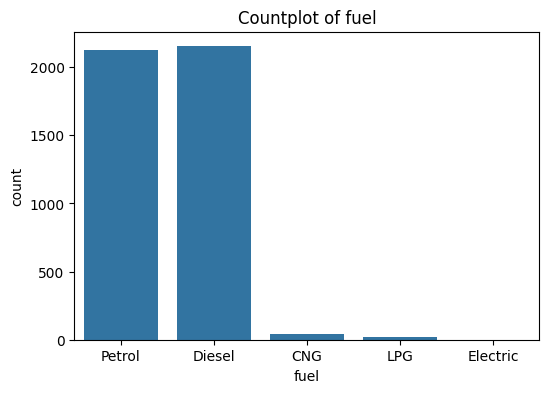

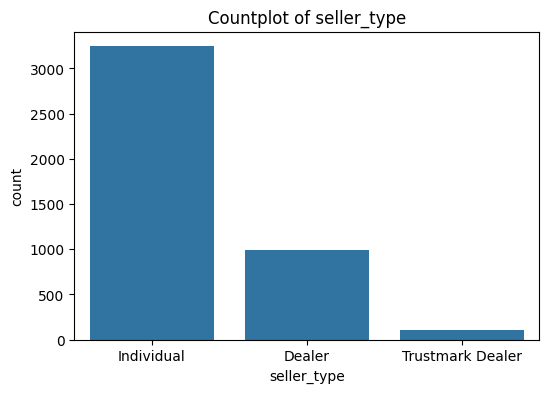

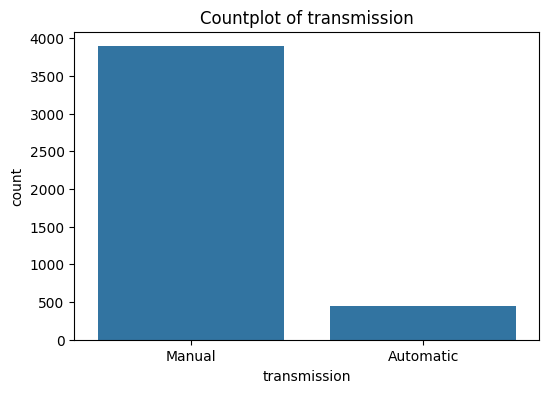

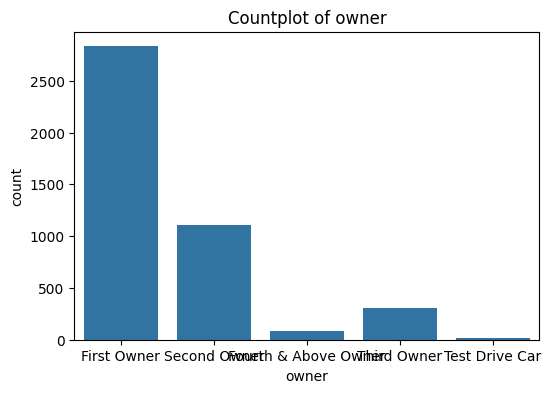

In [14]:
categorical_features = ['fuel','seller_type', 'transmission','owner']

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=data, x=feature)
    plt.title(f'Countplot of {feature}')
    plt.show()

### Conclusion:
* There are 5 Fuel_Type categories. Diesel has the highest frequency and CNG, LPG and Electric has the least frequency.
* There are 3 Seller_Type categories. Individual has the highest frequency and Trustmark Dealer has the least frequency.
* There are 2 Transmission categories. Manual has the highest frequency and Automatic has the least frequency.
* There are 5 Owner categories. First Owner has the higest frequency.

### Bivariate analysis

In [15]:
data.columns

Index(['Age', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner'],
      dtype='object')

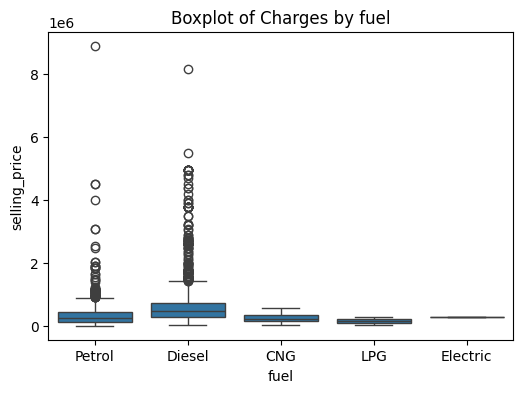

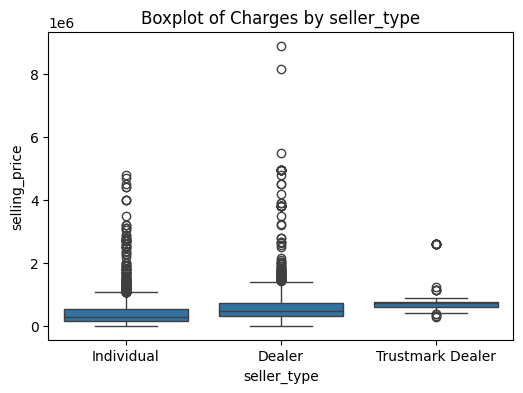

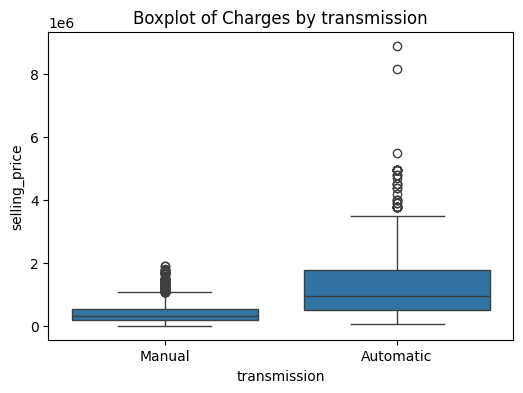

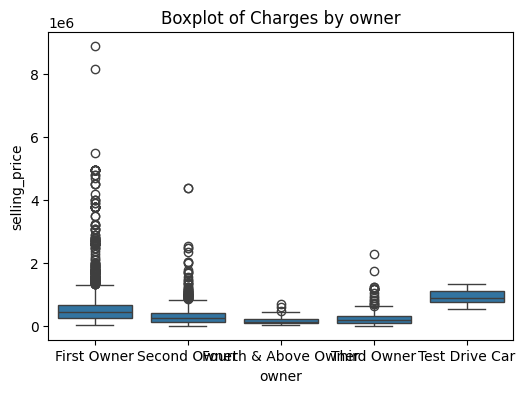

In [16]:
# Boxplots for selling price across categories
categorical_features = ['fuel','seller_type','transmission', 'owner']

for feature in categorical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=data, x=feature, y='selling_price')
    plt.title(f'Boxplot of Charges by {feature}')
    plt.show()

## Outlier Detection


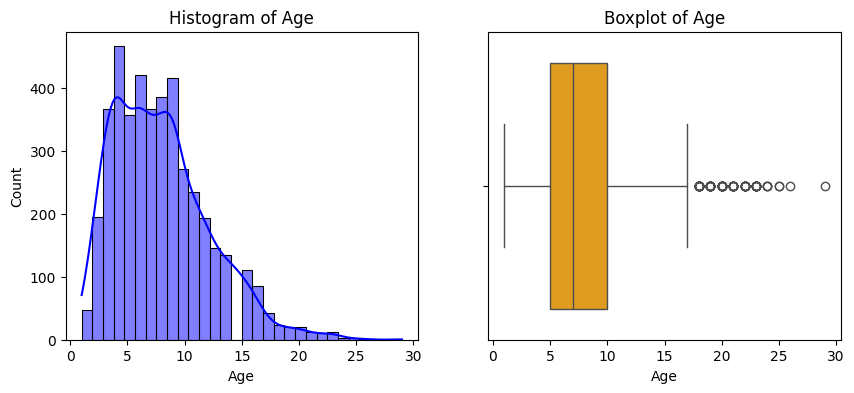

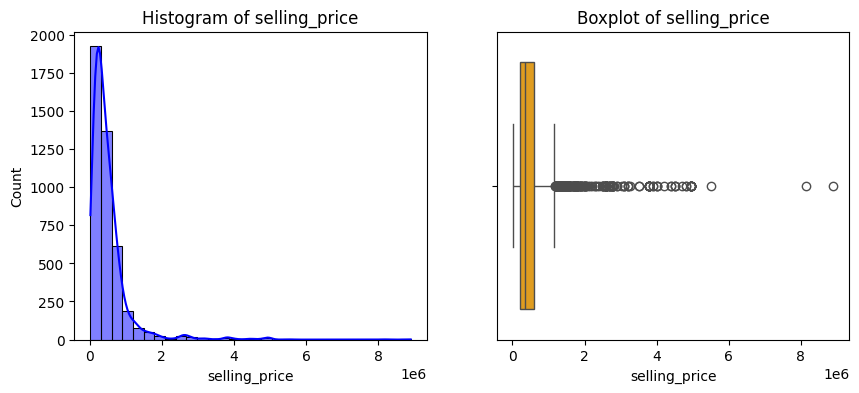

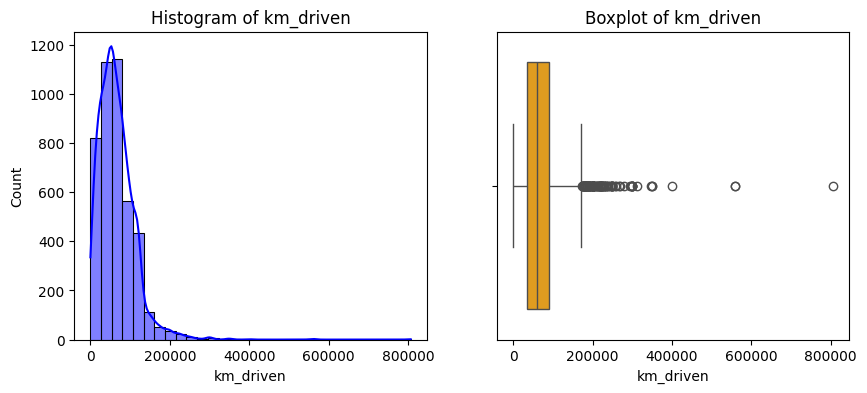

In [17]:
# Plot histograms and boxplots
numeric_features = ['Age', 'selling_price','km_driven']

for feature in numeric_features:
    plt.figure(figsize=(10, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data[feature], kde=True, bins=30, color='blue')
    plt.title(f'Histogram of {feature}')

    # Boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=data[feature], color='orange')
    plt.title(f'Boxplot of {feature}')

    plt.show()

It is not acceptable to drop an observation just because it is an outlier. They can be legitimate observations and it’s important to investigate the nature of the outlier before deciding whether to drop it or not. We are allowed to delete outliers in two cases:__

* __Outlier is due to incorrectly entered or measured data__
* __Outlier creates a significant association__

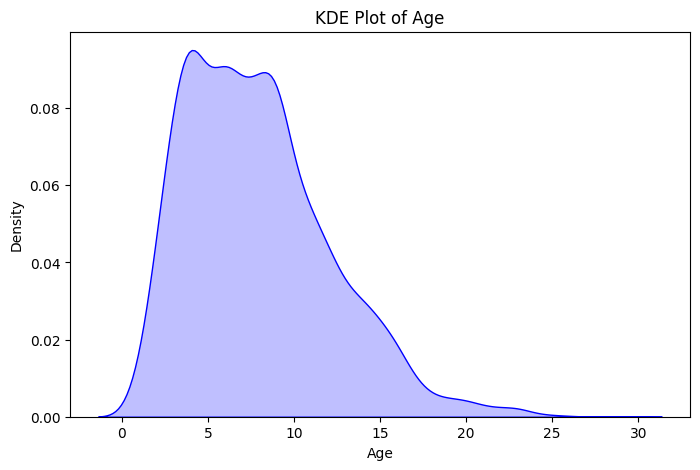

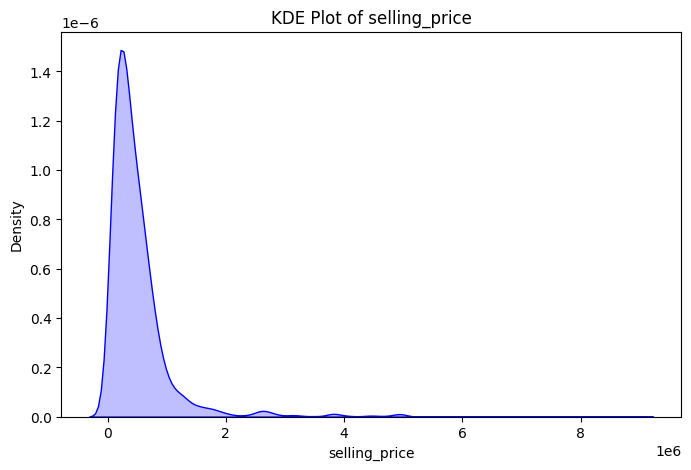

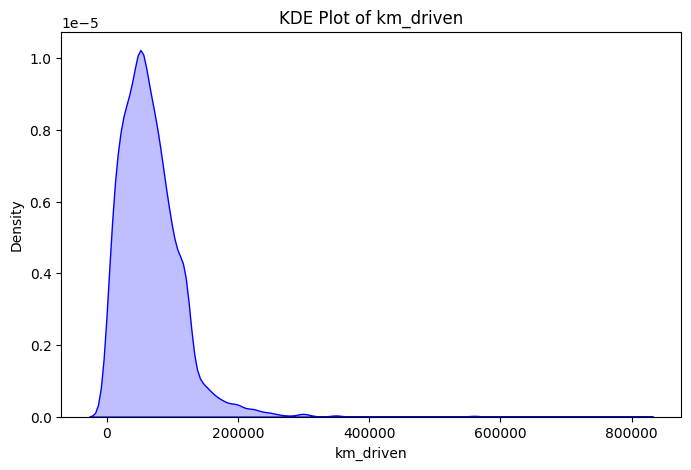

In [18]:
numeric_features = ['Age', 'selling_price', 'km_driven']

for feature in numeric_features:
    plt.figure(figsize=(8, 5))

    # KDE plot
    sns.kdeplot(data[feature], shade=True, color='blue')
    plt.title(f'KDE Plot of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Density')
    plt.show()

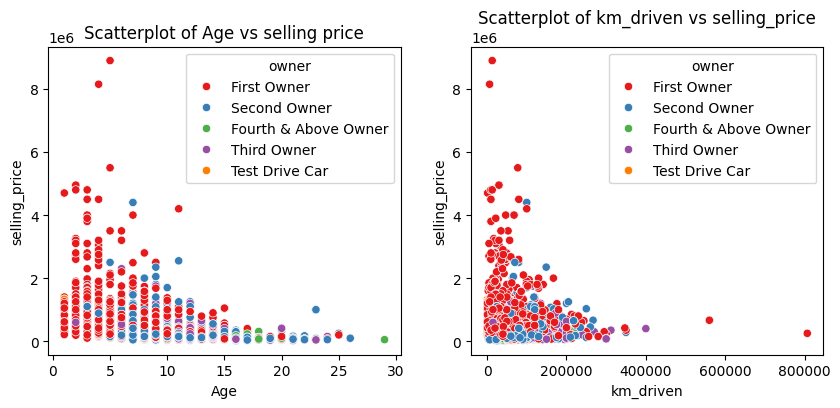

In [19]:
# Scatterplots for selling price vs other numeric features
plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
sns.scatterplot(data=data, x='Age', y='selling_price', hue='owner', palette='Set1')
plt.title(f'Scatterplot of Age vs selling price')

plt.subplot(1,2,2)
sns.scatterplot(data=data, x='km_driven', y='selling_price', hue='owner', palette='Set1')
plt.title(f'Scatterplot of km_driven vs selling_price')

plt.show()

## Categorical Variables Encoding
We implement dummy encoding on categorical columns, since they are all nominal variables:

In [20]:
categorical_features = ['fuel','seller_type','transmission', 'owner']

df_encoded = pd.get_dummies(data, columns=categorical_features, drop_first=True).astype(int)
df_encoded.head(5)

,Age,selling_price,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,14,60000,70000,0,0,0,1,1,0,1,0,0,0,0
1,14,135000,50000,0,0,0,1,1,0,1,0,0,0,0
2,9,600000,100000,1,0,0,0,1,0,1,0,0,0,0
3,4,250000,46000,0,0,0,1,1,0,1,0,0,0,0
4,7,450000,141000,1,0,0,0,1,0,1,0,1,0,0


## Correlation Analysis

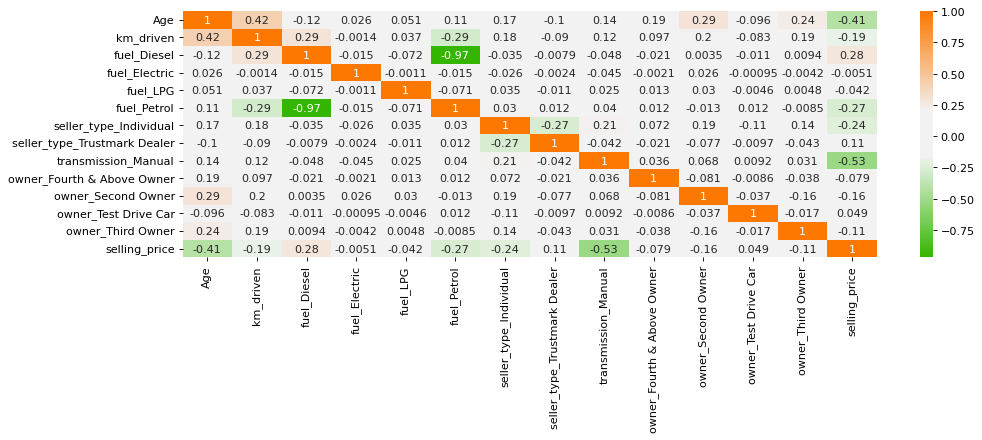

In [21]:
target = 'selling_price'
cmap = sns.diverging_palette(125, 28, s=100, l=65, sep=50, as_cmap=True)
fig, ax = plt.subplots(figsize=(14, 4), dpi=80)
ax = sns.heatmap(pd.concat([df_encoded.drop(target,axis=1), df_encoded[target]],axis=1).corr(), annot=True, cmap=cmap)
plt.show()

* The target variable "Selling Price" is highly correlated with Age & transmission & seller_type.
* Some independent variables like Fuel_Petrol and Fuel_Disel are highly correlated, which is called Multicollinearity.

## Split Data

In [22]:
X = df_encoded.drop('selling_price', axis=1)
y = df_encoded['selling_price']

In [23]:
X

,Age,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,14,70000,0,0,0,1,1,0,1,0,0,0,0
1,14,50000,0,0,0,1,1,0,1,0,0,0,0
2,9,100000,1,0,0,0,1,0,1,0,0,0,0
3,4,46000,0,0,0,1,1,0,1,0,0,0,0
4,7,141000,1,0,0,0,1,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,7,80000,1,0,0,0,1,0,1,0,1,0,0
4336,7,80000,1,0,0,0,1,0,1,0,1,0,0
4337,12,83000,0,0,0,1,1,0,1,0,1,0,0
4338,5,90000,1,0,0,0,1,0,1,0,0,0,0


## Split Dataset to Training & Test Sets

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
print('X_train shape: ', X_train.shape)
print('X_test shape: ', X_test.shape)
print('y_train shape: ', y_train.shape)
print('y_test shape: ',y_test.shape)

X_train shape:  (3472, 13)
X_test shape:  (868, 13)
y_train shape:  (3472,)
y_test shape:  (868,)


## Scale Data using Standard Scaler

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
X_train_scaled

array([[-0.92342078, -0.98114024,  1.01275414, ..., -0.58178467,
        -0.06587126, -0.27553931],
       [-1.16122801, -0.34146273,  1.01275414, ..., -0.58178467,
        -0.06587126, -0.27553931],
       [ 0.0278081 , -0.87452732, -0.98740648, ...,  1.71884901,
        -0.06587126, -0.27553931],
       ...,
       [-0.68561356, -0.32014015,  1.01275414, ..., -0.58178467,
        -0.06587126, -0.27553931],
       [ 0.0278081 ,  0.29821478,  1.01275414, ..., -0.58178467,
        -0.06587126, -0.27553931],
       [ 0.0278081 ,  0.29821478, -0.98740648, ..., -0.58178467,
        -0.06587126, -0.27553931]])

__It is very important that StandardScaler transformation should only be learnt from the training set, otherwise it will lead to data leakage.__

## Train the Model

In [28]:
from sklearn.linear_model import LinearRegression

linear_reg = LinearRegression()
linear_reg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
pd.DataFrame(data = np.append(linear_reg.intercept_ , linear_reg.coef_),
             index = ['Intercept']+[col+" Coef." for col in X.columns], columns=['Value']).sort_values('Value', ascending=False)

,Value
Intercept,507767.468318
fuel_Diesel Coef.,139914.155959
seller_type_Trustmark Dealer Coef.,25320.616048
owner_Test Drive Car Coef.,8570.854655
fuel_LPG Coef.,3841.002203
owner_Fourth & Above Owner Coef.,87.386207
owner_Third Owner Coef.,-6931.174889
fuel_Petrol Coef.,-10346.919035
fuel_Electric Coef.,-10861.968495
owner_Second Owner Coef.,-15667.732776


## Model Evaluation

In [30]:
from sklearn import metrics

def model_evaluation(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    MAE = metrics.mean_absolute_error(y_test, y_pred)
    MSE = metrics.mean_squared_error(y_test, y_pred)
    RMSE = np.sqrt(MSE)
    R2_Score = metrics.r2_score(y_test, y_pred)

    return pd.DataFrame([MAE, MSE, RMSE, R2_Score], index=['MAE', 'MSE', 'RMSE' ,'R2-Score'], columns=[model_name])

In [31]:
model_evaluation(linear_reg, X_train_scaled, y_train, 'Linear Reg.')

,Linear Reg.
MAE,2.340585e+05
MSE,1.807843e+11
RMSE,4.251874e+05
R2-Score,4.713029e-01


In [32]:
model_evaluation(linear_reg, X_test_scaled, y_test, 'Linear Reg.')

,Linear Reg.
MAE,2.217064e+05
MSE,1.821469e+11
RMSE,4.267867e+05
R2-Score,4.031304e-01


# Gradient Descent

In [ ]:
def gradient_descent(X, y, learning_rate=0.01, epochs=2000):

    m = X.shape[0]  # Number of samples
    n = X.shape[1]  # Number of features

    weights = np.zeros(n)  # Initialize weights to zeros : one for each feature
    cost_history = []      # store MSE for each epoch

    for epoch in range(epochs):
        predictions = np.dot(X, weights)  # Predicted values
        errors = predictions - y          # Errors

        gradients = (1 / m) * np.dot(X.T, errors)  # Compute gradients
        weights -= learning_rate * gradients  # Update weights

        # Compute cost (MSE)
        cost = (1 / (2 * m)) * np.sum(errors ** 2)
        cost_history.append(cost)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Cost = {cost}")

    return weights, cost_history

In [ ]:
# add the column of ones to X_train for the intercept (bias term)
X_train_np = np.hstack((np.ones((X_train_scaled.shape[0], 1)), X_train_scaled))

# converrt y_train into numpy array
y_train_np = y_train.values

weights, cost_history = gradient_descent(X_train_np, y_train_np, learning_rate=0.01, epochs=1000)

Epoch 0: Cost = 299885435816.6771
Epoch 100: Cost = 112964193306.54724
Epoch 200: Cost = 93603939030.21584
Epoch 300: Cost = 90950274457.33
Epoch 400: Cost = 90547301900.55424
Epoch 500: Cost = 90477068818.72098
Epoch 600: Cost = 90460889984.5487
Epoch 700: Cost = 90454979903.71487
Epoch 800: Cost = 90451534807.87514
Epoch 900: Cost = 90448871963.10217


In [ ]:
weights

array([ 507745.54736297, -149446.87440541,  -47552.06180049,
         87774.28574971,  -12679.75476679,   -3730.81265774,
        -62712.3654834 ,  -30166.86908034,   25469.72904028,
       -273099.9271047 ,    -704.89859069,  -16337.84151501,
          8694.79725674,   -7303.0801146 ])

In [ ]:
df_encoded.columns

Index(['Age', 'selling_price', 'km_driven', 'fuel_Diesel', 'fuel_Electric',
       'fuel_LPG', 'fuel_Petrol', 'seller_type_Individual',
       'seller_type_Trustmark Dealer', 'transmission_Manual',
       'owner_Fourth & Above Owner', 'owner_Second Owner',
       'owner_Test Drive Car', 'owner_Third Owner'],
      dtype='object')

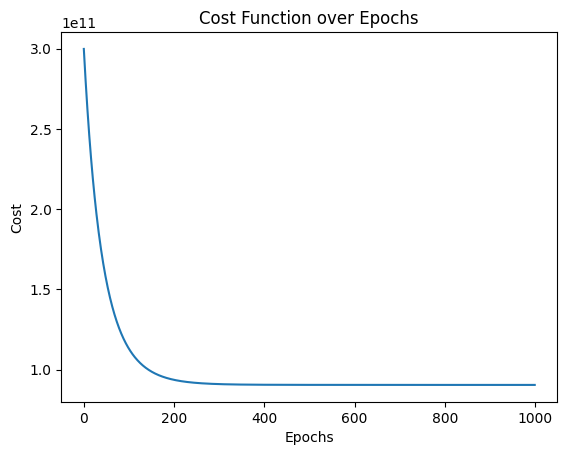

In [ ]:
# Example plotting cost history

plt.plot(range(len(cost_history)), cost_history)
plt.title("Cost Function over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.show()

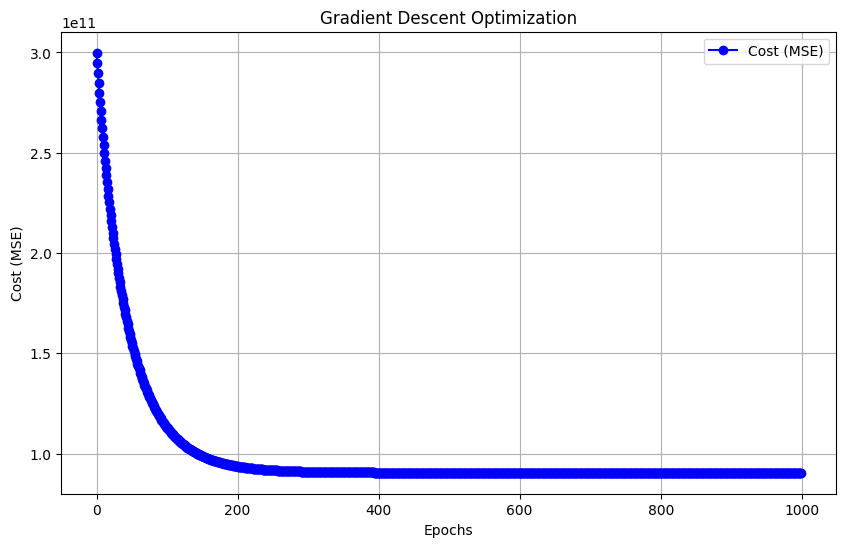

In [ ]:
import matplotlib.pyplot as plt

def visualize_gradient_descent(cost_history):
    plt.figure(figsize=(10, 6))
    plt.plot(range(len(cost_history)), cost_history, marker='o', linestyle='-', color='b', label='Cost (MSE)')
    plt.title("Gradient Descent Optimization")
    plt.xlabel("Epochs")
    plt.ylabel("Cost (MSE)")
    plt.grid(True)
    plt.legend()
    plt.show()

# Call the visualization function
visualize_gradient_descent(cost_history)

## Interpretation :

**Epoch-wise Cost Reduction:**

- The Cost is steadily decreasing over the epochs. It starts at a very high value `(299,885,435,816.6771 at epoch 0)` and gradually reduces to `90,448,871,963.10217` by epoch 900.
- This steady reduction in cost indicates that the model is learning and optimizing the weights effectively through gradient descent.

**Convergence:**

- Around epoch 400, the cost values start to stabilize and show only marginal improvements (e.g., from 90,547,301,900.55424 at epoch 400 to 90,448,871,963.10217 at epoch 900).
- This suggests that the model is nearing convergence, meaning the gradient descent process has mostly minimized the cost function.

**Learning Rate:**

- The learning rate appears appropriate since the cost is reducing gradually without sudden fluctuations or overshooting. If the learning rate were too high, the cost could oscillate or fail to converge.

**Overall Performance:**

While the gradient descent algorithm is successfully reducing the cost, the absolute values of the cost are still very high. This could indicate potential issues:

1. Features may need additional scaling or transformation.
2. The model might not be fully capturing the relationship between features and the target variable (e.g., non-linear relationships, multicollinearity).
3. Overfitting or underfitting could also be factors depending on how the model performs on test data.